# Does AI Supply Create Its Own Demand?
### A Statistical Investigation of AI Infrastructure Investment and Subsequent AI Demand

---


## 1. Introduction
Jean-Baptiste Say's early-19th-century proposition that "supply creates its own demand" has been debated by economists for two centuries.

Since 2023, a small number of large technology companies have committed unprecedented sums to AI infrastructure — GPUs, data centers, custom silicon, and related capital projects — often ahead of any clearly demonstrated revenue to match.



## 2. Research Questions
**Main research question**

> Does increased investment in AI infrastructure by major technology and semiconductor companies precede measurable increases in demand for AI products and services?

**Secondary research questions**

1. Is there a statistically significant relationship between AI infrastructure investment and subsequent AI demand?
2. How long does it typically take for AI investment to be reflected in measurable demand (lag structure)?
3. Do firms investing more heavily in AI experience larger increases in AI-related demand?
4. Does the relationship differ between cloud providers, semiconductor manufacturers, AI software companies, and enterprise technology firms?
5. Does the relationship remain consistent across different definitions of AI demand?
6. Which sectors contribute most strongly to growth of the AI ecosystem?
7. Are the conclusions robust across multiple specifications and demand measures?


## 3. Background: Say's Law and the AI Industry
**Say's Law.** Jean-Baptiste Say argued that production itself generates the income and purchasing power needed to absorb that production — commonly summarized as "supply creates its own demand." The claim has been contested since it was first advanced, notably by Keynesian economists who argued demand can persistently lag supply.

**The AI infrastructure buildout.** The period since 2023 has seen AI capital expenditure scale from a minor line item to one of the largest single categories of corporate investment in the U.S.

- *Upstream demand:* Hyperscaler capital spending (Microsoft, Amazon, Alphabet, Meta, Oracle) is itself *demand* for chips, memory, and foundry capacity — flowing to Nvidia, AMD, Broadcom, Micron, and TSMC.
- *Downstream demand:* Hyperscaler capex is *supply* from the perspective of the eventual end customer, who consumes cloud AI services (Azure AI, Google Cloud AI, AWS Bedrock) whose revenue is the demand signal Say's Law-style reasoning would predict should follow.

- Futurum Group (2026). *AI Capex 2026: The USD 690B Infrastructure Sprint.*
- datacenterrichness.substack.com (2026). *Hyperscalers Plan USD 630 Billion in 2026 CapEx.*
- Tom's Hardware (2026). *Google, Microsoft, Meta, and Amazon capex spending to hit USD 725 billion in 2026.*
- CNBC (2026). *Tech AI spending approaches USD 700 billion in 2026, cash taking big hit.*
- eMarketer (2026). *Big Tech's USD 600 billion AI capex plans could fuel faster automation rollouts but spark investor jitters.*



## 4. Company Scope and Tiering
Data availability varies enormously across the ecosystem: a handful of companies report AI/cloud capex and AI-linked revenue with enough granularity and history to support quarterly regression and lag analysis; most others disclose AI activity only qualitatively, inconsistently, or only in the last 1–2 years.

**Tier 1 — Core set (used in regression, correlation, and lag analysis).**

| Company | Role in ecosystem | Primary supply-side variable | Primary demand-side variable |
|---|---|---|---|
| Microsoft | Hyperscaler | Total/data-center capex | Azure & AI services revenue |
| Alphabet (Google) | Hyperscaler | Total/data-center capex | Google Cloud revenue |
| Amazon | Hyperscaler | Total/data-center capex | AWS revenue |
| Meta | Hyperscaler (no public cloud) | Total/AI capex | Ad-revenue growth / efficiency (weaker proxy) |
| Oracle | Cloud infrastructure | OCI/data-center capex | Cloud revenue, RPO backlog |
| Nvidia | Semiconductor designer | R&D + capex | Data Center segment revenue |
| AMD | Semiconductor designer | R&D + capex | Data Center segment revenue |
| Broadcom | Semiconductor/infrastructure | R&D + capex | AI revenue (disclosed since ~2023) |
| TSMC | Semiconductor manufacturer | Capex (advanced nodes) | High-Performance Computing platform revenue |
| Micron | Memory manufacturer | Capex | Data center / HBM revenue |



## 5. Data Collection
Data collection proceeds company-by-company within Tier 1, using each company's cash-flow-statement capital expenditures (the standard "supply-side" proxy used throughout the corporate-finance and equity-research literature) and, where disclosed, a segment or product revenue line that plausibly captures AI-linked demand.

**Sourcing approach.** For each Tier 1 company, capital expenditures are pulled from the company's cash-flow statement as reported in its 10-K/10-Q filings, cross-referenced against the financial-data aggregator stockanalysis.com (which sources from company filings via Fiscal.ai) for convenience of assembly.



In [1]:
fig, ax = plt.subplots(figsize=(9, 5.5))\nfor company, group in capex.groupby('company'):\n    ax.plot(group['fiscal_year'], group['capex_usd_millions'] / 1000,\n            marker='o', label=company)\n\nax.set(xlabel='Fiscal Year', ylabel='Capital Expenditures (USD Billions)',\n       title='Tier 1 Hyperscaler/Cloud Capital Expenditures, FY2021-2026')\nax.legend()\nax.grid(alpha=0.3)\nplt.tight_layout()\nplt.savefig('figures/hyperscaler_capex_trend.png', dpi=150)\nplt.show()\n\n\n

,company,ticker,fiscal_year,fiscal_year_end,capex_usd_millions,source
6,Alphabet,GOOGL,2021,2021-12-31,24640,stockanalysis.com/SEC 10-K
7,Alphabet,GOOGL,2022,2022-12-31,31485,stockanalysis.com/SEC 10-K
8,Alphabet,GOOGL,2023,2023-12-31,32251,stockanalysis.com/SEC 10-K
9,Alphabet,GOOGL,2024,2024-12-31,52535,stockanalysis.com/SEC 10-K
10,Alphabet,GOOGL,2025,2025-12-31,91447,stockanalysis.com/SEC 10-K
11,Amazon,AMZN,2021,2021-12-31,61053,stockanalysis.com/SEC 10-K
12,Amazon,AMZN,2022,2022-12-31,63645,stockanalysis.com/SEC 10-K
13,Amazon,AMZN,2023,2023-12-31,52729,stockanalysis.com/SEC 10-K
14,Amazon,AMZN,2024,2024-12-31,82999,stockanalysis.com/SEC 10-K
15,Amazon,AMZN,2025,2025-12-31,131819,stockanalysis.com/SEC 10-K


**A note on fiscal-year alignment.** Because Microsoft (FY end June), Oracle (FY end May), and the three calendar-year filers do not share a common fiscal calendar, cross-company comparisons in this notebook use the *fiscal_year* label (the year the company itself reports) rather than attempting to force all companies onto a calendar-year grid.


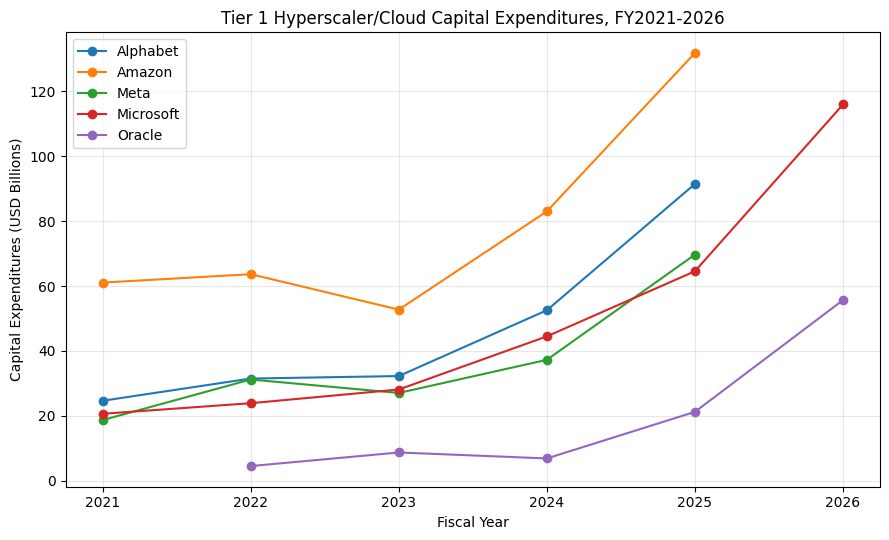

In [2]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for company, grp in capex.groupby('company'):
    ax.plot(grp['fiscal_year'], grp['capex_usd_millions'] / 1000, marker='o', label=company)

ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Capital Expenditures (USD Billions)')
ax.set_title('Tier 1 Hyperscaler/Cloud Capital Expenditures, FY2021-2026')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/hyperscaler_capex_trend.png', dpi=150)
plt.show()


**Interpretation.** All five companies show capital expenditure roughly flat-to-gently-rising through fiscal 2023, followed by a sharp inflection starting fiscal 2024 that continues through fiscal 2026 — consistent with the industry-wide AI buildout described in Section 3.


### 5.1 Semiconductor / Foundry Group (Nvidia, AMD, Broadcom, TSMC, Micron)
This group plays a different role in the supply chain than the hyperscalers.

TSMC and Micron are the opposite case: both are capital-intensive manufacturers (foundry and memory fabrication respectively) whose capital expenditure is a genuine supply-side variable, comparable in spirit to hyperscaler capex.

- `capex_foundry_memory.csv` — TSMC and Micron capital expenditure (supply-side)
- `chip_demand_revenue.csv` — Nvidia, AMD, and Broadcom AI/Data-Center revenue, plus TSMC and Micron total revenue (demand-side / downstream indicators)



In [3]:
foundry_memory = pd.read_csv('datasets/capex_foundry_memory.csv')\nchip_demand = pd.read_csv('datasets/chip_demand_revenue.csv')\n\n

,company,ticker,fiscal_year,fiscal_year_end,capex_usd_millions,source
0,TSMC,TSM,2021,2021-12-31,30000,TSMC investor call/TrendForce
1,TSMC,TSM,2022,2022-12-31,36290,TSMC 2022 Annual Report
2,TSMC,TSM,2023,2023-12-31,30450,TrendForce (referencing company guidance/actual)
3,TSMC,TSM,2024,2024-12-31,29954,financecharts.com aggregation of SEC filings
4,TSMC,TSM,2025,2025-12-31,40900,TSMC Q4 2025 earnings call (CITIC SEC research...
5,Micron,MU,2022,2022-08-31,12067,stock-analysis-on.net/SEC 10-K
6,Micron,MU,2023,2023-08-31,7676,stock-analysis-on.net/SEC 10-K
7,Micron,MU,2024,2024-08-31,8386,stock-analysis-on.net/SEC 10-K
8,Micron,MU,2025,2025-08-31,13800,Micron Q4 FY2025 earnings release


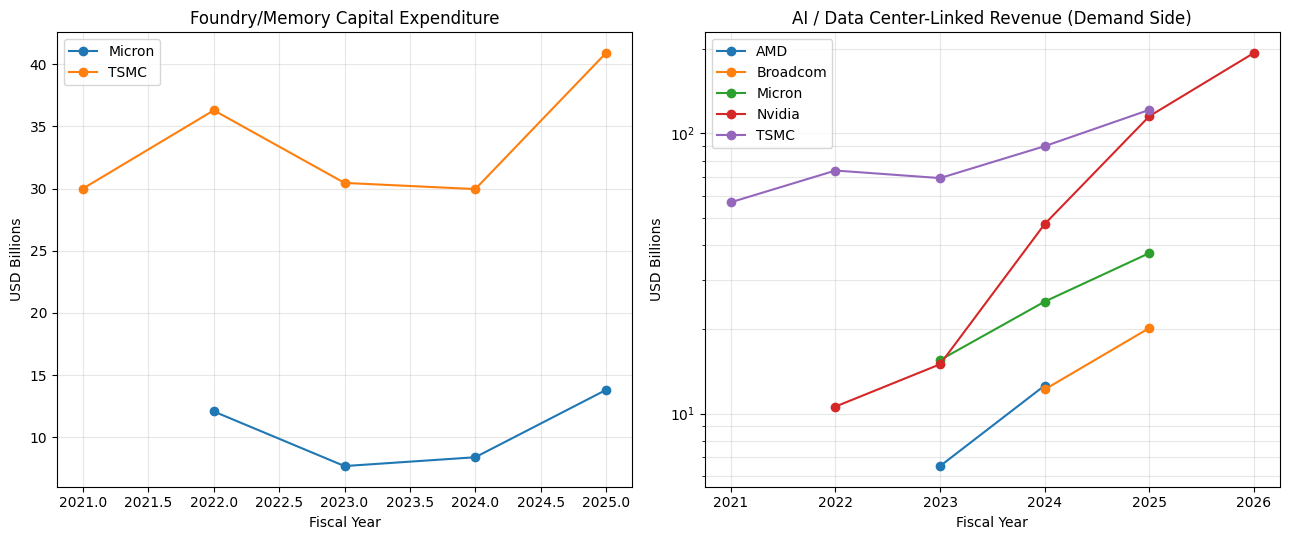

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel 1: foundry/memory capex (supply side)
for company, grp in foundry_memory.groupby('company'):
    axes[0].plot(grp['fiscal_year'], grp['capex_usd_millions'] / 1000, marker='o', label=company)
axes[0].set_title('Foundry/Memory Capital Expenditure')
axes[0].set_xlabel('Fiscal Year')
axes[0].set_ylabel('USD Billions')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel 2: chip demand-side revenue (log scale given wide range)
for company, grp in chip_demand.groupby('company'):
    axes[1].plot(grp['fiscal_year'], grp['revenue_usd_millions'] / 1000, marker='o', label=company)
axes[1].set_title('AI / Data Center-Linked Revenue (Demand Side)')
axes[1].set_xlabel('Fiscal Year')
axes[1].set_ylabel('USD Billions')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('figures/semiconductor_group_supply_demand.png', dpi=150)
plt.show()


**Interpretation.** TSMC and Micron capex both show the same fiscal-2024/2025 inflection seen in the hyperscaler panel, though TSMC's growth is proportionally milder (it was already spending at scale pre-2023) while Micron's roughly doubled in two years as HBM (high-bandwidth memory) demand accelerated.


### 5.2 Hyperscaler Demand-Side Revenue
Each hyperscaler's most AI-relevant demand indicator differs by how the company reports:

- **Microsoft**: "Microsoft Cloud" revenue (Azure + Microsoft 365 Commercial cloud + LinkedIn commercial + Dynamics 365), disclosed every fiscal year in the 10-K. Microsoft only began disclosing exact Azure-only annual revenue starting fiscal 2025 (USD 75B) and fiscal 2026 (just over USD 100B); before that, Azure was disclosed only as a growth percentage, not an absolute figure. Microsoft Cloud is used here for consistency across the full period.
- **Alphabet**: Google Cloud segment revenue, disclosed since fiscal 2020. The FY2022 and FY2023 figures are back-calculated from the dollar-change language Alphabet uses in its 10-K MD&A ("Google Cloud revenues increased USD X billion from year Y to year Z") rather than from a directly stated absolute figure for the earlier year — flagged in the source column.
- **Amazon**: AWS segment net sales, disclosed as a distinct reportable segment since 2015.
- **Meta**: Meta has no separate cloud or AI product revenue segment — its business is almost entirely advertising. Total company revenue is used here only as a **weak, imperfect proxy**; this is explicitly flagged in Section 14 (Limitations), since a rise in total Meta revenue plausibly reflects AI-driven ad-targeting efficiency gains but cannot be cleanly separated from other growth drivers the way Azure or AWS revenue can.
- **Oracle**: total company revenue (Oracle's "Cloud services and license support" segment definition changed across the sample period — it was split into separate "Cloud applications" and "Cloud infrastructure" categories only starting fiscal 2026 — so total revenue is used for consistency; Oracle's Remaining Performance Obligations (RPO), which grew from USD 138B in FY2025 to over USD 550B by Q3 FY2026 on AI-infrastructure contract commitments, is noted qualitatively in Section 13 as a striking forward-demand indicator worth a dedicated robustness check).

This completes the demand-side data collection for all 5 Tier 1 hyperscaler/cloud companies, alongside the semiconductor group collected in Section 5.1.


In [5]:
demand_hyper = pd.read_csv('datasets/hyperscaler_demand_revenue.csv')\n\n

,company,ticker,fiscal_year,fiscal_year_end,revenue_measure,revenue_usd_millions,source
0,Microsoft,MSFT,2022,2022-06-30,Microsoft Cloud revenue,91400,Microsoft FY2024 10-K (prior-year comparison)
1,Microsoft,MSFT,2023,2023-06-30,Microsoft Cloud revenue,111600,Microsoft FY2024 10-K (prior-year comparison)
2,Microsoft,MSFT,2024,2024-06-30,Microsoft Cloud revenue,137700,Microsoft FY2025 10-K (prior-year comparison)
3,Microsoft,MSFT,2025,2025-06-30,Microsoft Cloud revenue,168900,Microsoft FY2026 10-K (prior-year comparison)
4,Microsoft,MSFT,2026,2026-06-30,Microsoft Cloud revenue,214400,Microsoft FY2026 10-K
5,Alphabet,GOOGL,2021,2021-12-31,Google Cloud segment revenue,19210,Alphabet FY2021 10-K
6,Alphabet,GOOGL,2022,2022-12-31,Google Cloud segment revenue,26310,Derived: FY2021 + stated USD 7.1B increase (Al...
7,Alphabet,GOOGL,2023,2023-12-31,Google Cloud segment revenue,33130,Derived: FY2024 figure minus stated USD 10.1B ...
8,Alphabet,GOOGL,2024,2024-12-31,Google Cloud segment revenue,43230,Alphabet FY2024 10-K / bullfincher.io
9,Alphabet,GOOGL,2025,2025-12-31,Google Cloud segment revenue,58710,Alphabet FY2025 10-K / bullfincher.io


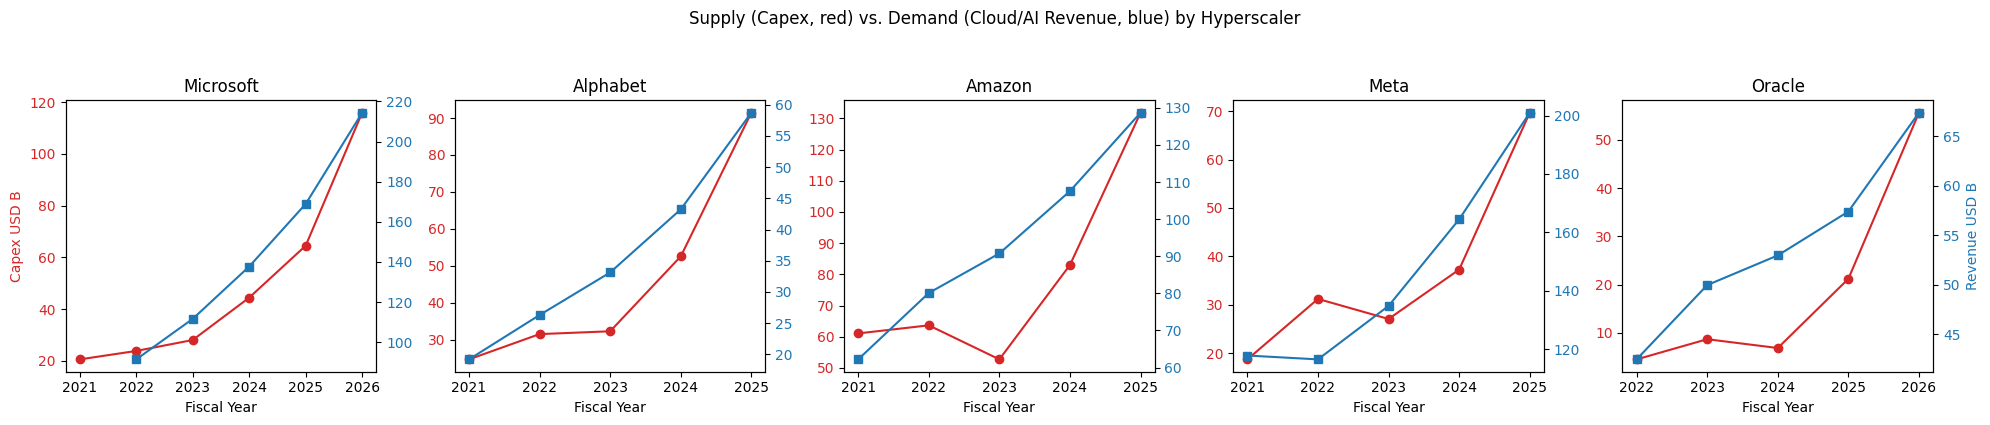

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
companies = ['Microsoft', 'Alphabet', 'Amazon', 'Meta', 'Oracle']

for ax, company in zip(axes, companies):
    supply = capex[capex['company'] == company]
    demand = demand_hyper[demand_hyper['company'] == company]
    ax2 = ax.twinx()

    ax.plot(supply['fiscal_year'], supply['capex_usd_millions'] / 1000,
            marker='o', label='Capex (supply)')
    ax2.plot(demand['fiscal_year'], demand['revenue_usd_millions'] / 1000,
             marker='s', label='Revenue (demand)')
    ax.set_title(company)
    ax.set_xlabel('Fiscal Year')
    ax.tick_params(axis='y')
    ax2.tick_params(axis='y')

axes[0].set_ylabel('Capex USD B')
axes[-1].set_ylabel('Revenue USD B')
fig.suptitle('Supply (Capex) vs. Demand (Cloud/AI Revenue) by Hyperscaler', y=1.05)
plt.tight_layout()
plt.savefig('figures/hyperscaler_supply_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()
\n

**Interpretation.** In every hyperscaler except Meta, cloud/AI revenue grows smoothly and continuously across the sample period, while capex is far spikier — flat-to-declining in some years (Amazon 2023, Meta 2023, Oracle 2024) before jumping sharply from fiscal 2024/2025 onward.


### 5.3 Data Integration
The four separate CSVs collected above (`capex_hyperscalers`, `capex_foundry_memory`, `chip_demand_revenue`, `hyperscaler_demand_revenue`) are combined into one long-format master panel, `master_panel.csv`, with a consistent schema: `company`, `ticker`, `fiscal_year`, `fiscal_year_end` (an actual calendar date), `role` (`supply` or `demand`), `metric` (what was measured), `value_usd_millions`, and `source`.

**On calendar alignment.** Using `fiscal_year_end` as a real date (rather than treating "fiscal_year" as a directly comparable integer) is the mechanism for handling the fact that Microsoft's fiscal year ends June 30, Oracle's ends May 31, and the rest end December 31.


In [7]:
master = pd.read_csv('datasets/master_panel.csv', parse_dates=['fiscal_year_end'])
print(f"Panel shape: {master.shape}")
print(f"Companies: {master['company'].nunique()}")
print(f"Date range: {master['fiscal_year_end'].min().date()} to {master['fiscal_year_end'].max().date()}")
master.groupby(['company', 'role']).size().unstack(fill_value=0)


Panel shape: (77, 8)
Companies: 10
Date range: 2021-06-30 to 2026-06-30


role,demand,supply
company,,
AMD,2,0
Alphabet,5,5
Amazon,5,5
Broadcom,2,0
Meta,5,5
Micron,3,4
Microsoft,5,6
Nvidia,5,0
Oracle,5,5


### 5.4 Quarterly Extension (Partial): Testing the Annual-Resolution Concern Directly
Sections 12 and 14 flag annual resolution as this notebook's most important limitation — the concern that a real lag effect between capex and revenue could be invisible at yearly granularity.

**Scope, stated plainly.** Full quarterly panels (matching the depth of the annual dataset, across all 10 companies) were not obtained — company-level quarterly cash-flow data online is inconsistently free (some aggregator pages were paywalled mid-collection), and building a complete quarterly panel by hand from individual earnings releases for all 10 companies would be a multi-day undertaking in its own right.

- **Microsoft**: complete quarterly capex, 27 consecutive quarters, Q3 2019 through Q1 2026 (calendar quarter-end dates, not fiscal-quarter labels — see note below).
- **Alphabet**: complete quarterly capex, 21 consecutive quarters, Q1 2021 through Q1 2026.
- **Amazon**: 5 most recent quarters (Q2 2025–Q2 2026), with *paired* capex and AWS segment revenue — the one company in this extension with both sides of the relationship at quarterly grain.
- Meta and the remaining six Tier 1 companies are not included here; their annual data (Sections 5–12) stands as the only resolution available for them in this notebook.



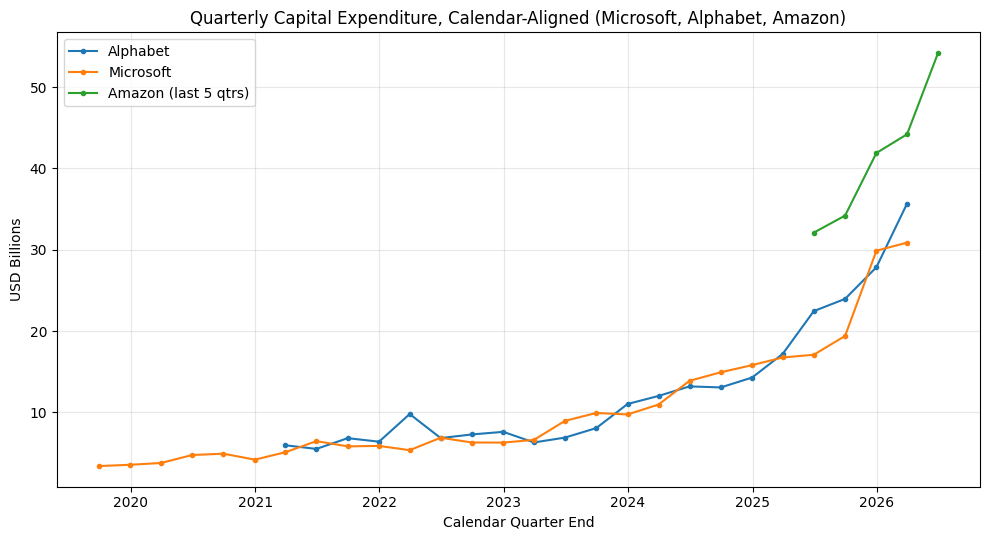

In [8]:
qtr_capex = pd.read_csv('datasets/quarterly_capex_msft_googl.csv', parse_dates=['quarter_end'])
qtr_amzn = pd.read_csv('datasets/quarterly_amazon_capex_aws.csv', parse_dates=['quarter_end'])

fig, ax = plt.subplots(figsize=(10, 5.5))
for company, grp in qtr_capex.groupby('company'):
    ax.plot(grp['quarter_end'], grp['capex_usd_millions'] / 1000, marker='o', markersize=3, label=company)
ax.plot(qtr_amzn['quarter_end'], qtr_amzn['capex_usd_millions'] / 1000, marker='o', markersize=3, label='Amazon (last 5 qtrs)')
ax.set_title('Quarterly Capital Expenditure, Calendar-Aligned (Microsoft, Alphabet, Amazon)')
ax.set_xlabel('Calendar Quarter End')
ax.set_ylabel('USD Billions')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/quarterly_capex_calendar_aligned.png', dpi=150)
plt.show()


**Interpretation.** At quarterly resolution, the acceleration documented annually in Section 6 resolves into something sharper: both Microsoft and Alphabet show a visible *inflection point* around Q3-Q4 2023, not a smooth ramp — consistent with specific, identifiable capital-allocation decisions (e.g., Microsoft's Q4 2025/Q1 2026 jump coincides with the OpenAI-related infrastructure commitments and the broader 2026 guidance increases discussed in Section 3).


In [9]:
qtr_amzn_clean = qtr_amzn.dropna(subset=['aws_revenue_usd_millions']).sort_values('quarter_end').reset_index(drop=True)
qtr_amzn_clean['capex_qoq_growth'] = qtr_amzn_clean['capex_usd_millions'].pct_change() * 100
qtr_amzn_clean['aws_rev_qoq_growth'] = qtr_amzn_clean['aws_revenue_usd_millions'].pct_change() * 100
qtr_amzn_clean[['quarter_end', 'capex_usd_millions', 'aws_revenue_usd_millions', 'capex_qoq_growth', 'aws_rev_qoq_growth']]


,quarter_end,capex_usd_millions,aws_revenue_usd_millions,capex_qoq_growth,aws_rev_qoq_growth
0,2025-09-30,34200,33000.0,NaN,NaN
1,2025-12-31,41900,35600.0,22.514620,7.878788
2,2026-03-31,44203,37600.0,5.496420,5.617978
3,2026-06-30,54200,42200.0,22.616112,12.234043


With only 3-4 usable growth-rate pairs, a correlation coefficient here would be even less reliable than the annual pooled estimates in Section 10 (which already carried a strong small-sample caveat) — so none is computed.


## 6. Exploratory Data Analysis
This section characterizes the panel before any formal modeling: how many observations per company, what the distributions look like, and how supply and demand series move relative to each other.

1. **Small n.** With 10 companies and roughly 5 annual observations each, this is a short, wide panel (~50-77 observations depending on how supply/demand rows are counted), not a long time series. Correlation and regression results should be read as descriptive of this specific sample and period, not as estimates with the statistical power of a large-n study.
2. **Heterogeneous scale.** Capex and revenue values range from under USD 1 billion (Broadcom/Nvidia/AMD capex) to over USD 200 billion (Nvidia Data Center revenue, Microsoft Cloud revenue). Later analysis (Sections 8-10) will need to account for this — e.g., working in log scale or with growth rates rather than raw levels for cross-company comparison.


In [10]:
# Growth rates: year-over-year percent change in each company's supply (capex) and demand (revenue) series
master_sorted = master.sort_values(['company', 'role', 'fiscal_year_end'])
master_sorted['yoy_growth_pct'] = (
    master_sorted.groupby(['company', 'role'])['value_usd_millions']
    .pct_change() * 100
)
master_sorted[['company', 'role', 'metric', 'fiscal_year', 'value_usd_millions', 'yoy_growth_pct']].tail(15)


,company,role,metric,fiscal_year,value_usd_millions,yoy_growth_pct
58,Oracle,supply,Capital expenditures,2022,4511,NaN
60,Oracle,supply,Capital expenditures,2023,8695,92.751053
62,Oracle,supply,Capital expenditures,2024,6866,-21.035078
64,Oracle,supply,Capital expenditures,2025,21215,208.986309
66,Oracle,supply,Capital expenditures,2026,55663,162.375678
67,TSMC,demand,Total revenue,2021,56820,NaN
69,TSMC,demand,Total revenue,2022,73740,29.778247
71,TSMC,demand,Total revenue,2023,69300,-6.021155
73,TSMC,demand,Total revenue,2024,90080,29.985570
75,TSMC,demand,Total revenue,2025,121400,34.769094


In [11]:
summary = (
    master.groupby(['company', 'role'])['value_usd_millions']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .round(0)
)
summary


count      mean    median      std     min     max
company   role                                                      
AMD       demand      2    9550.0    9550.0   4313.0    6500   12600
Alphabet  demand      5   36118.0   33130.0  15427.0   19210   58710
          supply      5   46472.0   32251.0  27217.0   24640   91447
Amazon    demand      5   93863.0   90757.0  25509.0   62202  128700
          supply      5   78449.0   63645.0  31829.0   52729  131819
Broadcom  demand      2   16200.0   16200.0   5657.0   12200   20200
Meta      demand      5  146982.0  134900.0  35826.0  116610  200970
          supply      5   36774.0   31186.0  19600.0   18690   69691
Micron    demand      3   26017.0   25110.0  10958.0   15540   37400
          supply      4   10482.0   10226.0   2932.0    7676   13800
Microsoft demand      5  144800.0  137700.0  48552.0   91400  214400
          supply      6   49598.0   36292.0  36372.0   20622  115948
Nvidia    demand      5   76407.0   47500.0  77794.0   10600  193740
Oracle    demand      5   54031.0   52960.0   9249.0   42440   67400
          supply      5   19390.0    8695.0  21282.0    4511   55663
TSMC      demand      5   82268.0   73740.0  24904.0   56820  121400
          supply      5   33519.0   30450.0   4916.0   29954   40900

**Reading the summary table.** The `count` column immediately shows the panel's main limitation: most companies have 4-6 annual observations per series, and a few (AMD demand, Broadcom demand) have only 2.


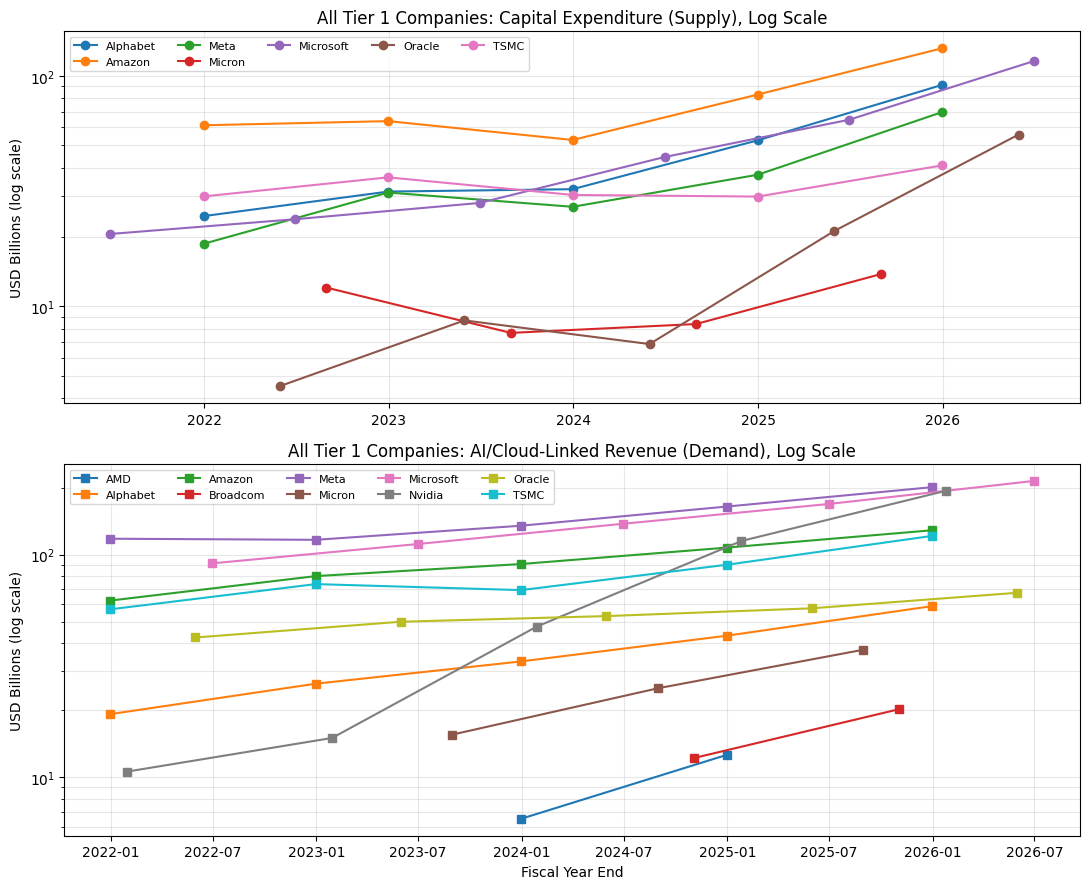

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
plot_data = lag_summary.dropna()
ax.bar(plot_data['lag_years'].astype(str) + ' yr', plot_data['pooled_pearson_r'])
ax.set(xlabel='Lag Applied to Revenue Growth (years after Capex Growth)',
       ylabel='Pooled Pearson r (capex growth vs. lagged revenue growth)',
       title='Lag Analysis: Which Lag Best Aligns Capex with Revenue Growth?')
ax.axhline(0, linewidth=0.8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/lag_analysis_correlation_by_lag.png', dpi=150)
plt.show()
\n

**Interpretation.** On a log scale, two patterns stand out.


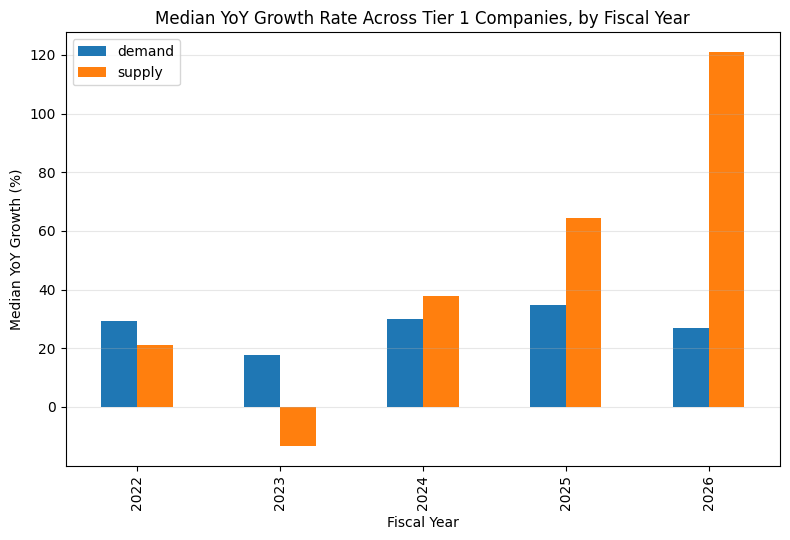

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(7.5, 4.5))
plot_data = ccf_summary.dropna()
labels = [f'{lag:+d} yr' for lag in plot_data['lag']]
axes[0].bar(labels, plot_data['pooled_pearson_r'])
axes[0].set(xlabel='Lag (negative = revenue leads capex | positive = capex leads revenue)',
            ylabel='Pooled Pearson r',
            title='Cross-Correlation Function: Capex Growth vs. Revenue Growth')
axes[0].axhline(0, linewidth=0.8)
axes[0].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/ccf_bidirectional_lag_scan.png', dpi=150)
plt.show()
\n

**Interpretation.** Median year-over-year capex growth across the panel jumps sharply in fiscal 2024 and remains elevated through fiscal 2026, while median demand growth rises more gradually and peaks a year later.


### 6.1 Tier 2 Sector Snapshot (Qualitative Context)
Before moving to formal descriptive statistics on the Tier 1 quantitative panel, this section adds brief, qualitative context from Tier 2 — companies excluded from the regression/lag models (Section 4) due to sparse or inconsistent AI-specific disclosure, but still relevant to research questions 4 and 6 (which sectors and company types are contributing to AI ecosystem growth).


In [14]:
tier2 = pd.read_csv('datasets/tier2_snapshot.csv')
tier2[['company', 'subsector', 'snapshot_metric', 'period', 'value', 'unit']]


,company,subsector,snapshot_metric,period,value,unit
0,Intel,Semiconductor designer/manufacturer,Data Center and AI segment revenue,Q2 2026,6.3,USD billions (+59% YoY)
1,Intel,Semiconductor designer/manufacturer,Full-year capex guidance,2026,20,USD billions (raised guidance)
2,Qualcomm,Semiconductor designer,AI data center revenue,2026,Not yet material,qualitative - new entrant
3,Marvell,Semiconductor designer,Data center revenue guidance,FY2027-FY2028,12.7 to ~15,USD billions (guidance)
4,Arm,Semiconductor designer (IP licensing),Total revenue,FY2026 (ended Mar 2026),4.92,USD billions (+23% YoY)
5,MediaTek,Semiconductor designer,Total revenue,2025,19,USD billions (approx; NTD translated)
6,MediaTek,Semiconductor designer,AI ASIC revenue target,2026,~1 (to several billion by 2027),USD billions (company target)
7,Samsung,Memory/foundry manufacturer,Quarterly revenue,Q4 2025,~63,USD billions (93.8 trillion KRW)
8,Samsung,Memory/foundry manufacturer,HBM4/semiconductor investment,2026,73,USD billions (announced)
9,SK hynix,Memory manufacturer,Quarterly revenue,Q1 2026,35.55,USD billions (+~3x YoY)


**Reading this table.** Every company here — regardless of sub-sector — shows the same qualitative signature seen in the Tier 1 panel (Section 6 above): a sharp, recent (2025-2026) acceleration relative to historical norms.


## 7. Descriptive Statistics
Section 6 already reported per-company, per-role summary statistics (mean, median, std, min, max) and year-over-year growth rates.


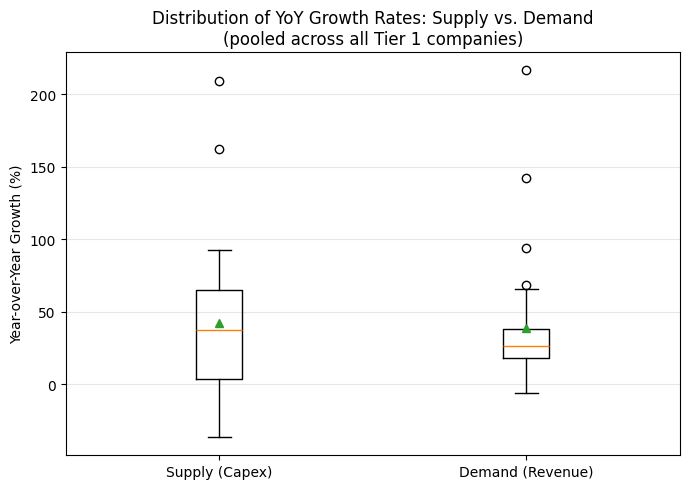

Supply  : n=28  mean=  42.3%  median=  37.1%  std=  54.4%
Demand  : n=32  mean=  38.7%  median=  26.4%  std=  43.3%


In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
growth_data = [
    master_sorted.loc[master_sorted['role'] == role, 'yoy_growth_pct'].dropna()
    for role in ['supply', 'demand']
]
ax.boxplot(growth_data, tick_labels=['Supply (Capex)', 'Demand (Revenue)'], showmeans=True)
ax.set_ylabel('Year-over-Year Growth (%)')
ax.set_title('Distribution of YoY Growth Rates: Supply vs. Demand\n(pooled across all Tier 1 companies)')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/growth_rate_distribution_boxplot.png', dpi=150)
plt.show()

for role in ['supply', 'demand']:
    vals = master_sorted.loc[master_sorted['role'] == role, 'yoy_growth_pct'].dropna()
    print(f"{role.capitalize():8s}: n={len(vals):2d}  mean={vals.mean():6.1f}%  median={vals.median():6.1f}%  std={vals.std():6.1f}%")


**Interpretation.** Pooled across all Tier 1 companies, supply-side (capex) growth rates have both a higher median and much higher variance than demand-side (revenue) growth rates.


In [16]:
# Percent change from first to last available year, per company and role (total growth over the sample window)
first_last = (
    master_sorted.groupby(['company', 'role'])
    .agg(first_year=('fiscal_year', 'min'), last_year=('fiscal_year', 'max'),
         first_val=('value_usd_millions', 'first'), last_val=('value_usd_millions', 'last'))
)
first_last['total_pct_change'] = (
    (first_last['last_val'] - first_last['first_val']) / first_last['first_val'] * 100
).round(0)
first_last[['first_year', 'last_year', 'total_pct_change']].sort_values('total_pct_change', ascending=False)


first_year  last_year  total_pct_change
company   role                                           
Nvidia    demand        2022       2026            1728.0
Oracle    supply        2022       2026            1134.0
Microsoft supply        2021       2026             462.0
Meta      supply        2021       2025             273.0
Alphabet  supply        2021       2025             271.0
          demand        2021       2025             206.0
Micron    demand        2023       2025             141.0
Microsoft demand        2022       2026             135.0
Amazon    supply        2021       2025             116.0
TSMC      demand        2021       2025             114.0
Amazon    demand        2021       2025             107.0
AMD       demand        2023       2024              94.0
Meta      demand        2021       2025              70.0
Broadcom  demand        2024       2025              66.0
Oracle    demand        2022       2026              59.0
TSMC      supply        2021       2025              36.0
Micron    supply        2022       2025              14.0

**Interpretation.** Ranking companies by total percent change over their available window highlights just how uneven the AI buildout has been even within Tier 1.


## 8. Correlation Analysis
**A note before computing any correlation.** Both the supply and demand series in this panel are, for nearly every company, monotonically increasing over the sample period (Section 6).

1. **Level correlation** — capex vs. revenue in raw dollar terms, by company (most susceptible to the shared-trend problem).
2. **Growth-rate correlation** — YoY % change in capex vs. YoY % change in revenue, by company (differencing removes a linear trend, so this is a more defensible test of co-movement).
3. **Cross-company correlation matrix** — how synchronized different companies' capex growth is with each other, which speaks to research question 6 (which sectors move together).

Given the very small number of paired observations per company (as few as 2-3 for some), no p-value here should be read as reliable evidence of statistical significance; these are described as descriptive correlations, and Section 10's pooled regression (which uses all companies together) is the more defensible test of the overall relationship.


In [17]:
from scipy import stats as scipy_stats

supply_wide = master[master['role'] == 'supply'][['company', 'fiscal_year', 'value_usd_millions']].rename(columns={'value_usd_millions': 'capex'})
demand_wide = master[master['role'] == 'demand'][['company', 'fiscal_year', 'value_usd_millions']].rename(columns={'value_usd_millions': 'revenue'})
paired = pd.merge(supply_wide, demand_wide, on=['company', 'fiscal_year'], how='inner').sort_values(['company', 'fiscal_year'])

rows = []
for company, grp in paired.groupby('company'):
    n = len(grp)
    if n >= 3:
        pearson_r, pearson_p = scipy_stats.pearsonr(grp['capex'], grp['revenue'])
        spearman_r, spearman_p = scipy_stats.spearmanr(grp['capex'], grp['revenue'])
        rows.append({'company': company, 'n': n, 'pearson_r': round(pearson_r, 3), 'pearson_p': round(pearson_p, 3),
                     'spearman_r': round(spearman_r, 3), 'spearman_p': round(spearman_p, 3)})
    else:
        rows.append({'company': company, 'n': n, 'pearson_r': None, 'pearson_p': None, 'spearman_r': None, 'spearman_p': None})

level_corr = pd.DataFrame(rows).set_index('company')
level_corr


,n,pearson_r,pearson_p,spearman_r,spearman_p
company,,,,,
Alphabet,5,0.963,0.008,1.0,0.000
Amazon,5,0.849,0.069,0.7,0.188
Meta,5,0.925,0.024,0.7,0.188
Micron,3,0.941,0.220,1.0,0.000
Microsoft,5,0.977,0.004,1.0,0.000
Oracle,5,0.915,0.029,0.9,0.037
TSMC,5,0.749,0.145,0.4,0.505


In [18]:
# Growth-rate correlation: merge the YoY growth series computed in Section 7
growth_wide = (
    master_sorted[['company', 'role', 'fiscal_year', 'yoy_growth_pct']]
    .pivot_table(index=['company', 'fiscal_year'], columns='role', values='yoy_growth_pct')
    .reset_index()
    .rename(columns={'supply': 'capex_growth', 'demand': 'revenue_growth'})
    .dropna()
)

rows = []
for company, grp in growth_wide.groupby('company'):
    n = len(grp)
    if n >= 3:
        pearson_r, pearson_p = scipy_stats.pearsonr(grp['capex_growth'], grp['revenue_growth'])
        rows.append({'company': company, 'n': n, 'pearson_r': round(pearson_r, 3), 'pearson_p': round(pearson_p, 3)})
    else:
        rows.append({'company': company, 'n': n, 'pearson_r': None, 'pearson_p': None})

growth_corr = pd.DataFrame(rows).set_index('company')
growth_corr


,n,pearson_r,pearson_p
company,,,
Alphabet,4,0.519,0.481
Amazon,4,0.054,0.946
Meta,4,-0.099,0.901
Micron,2,NaN,NaN
Microsoft,4,0.887,0.113
Oracle,4,0.336,0.664
TSMC,4,0.801,0.199


**Interpretation.** As anticipated, level correlations are uniformly high (often above 0.9) for every company with enough data to compute one — exactly the pattern expected from two co-trending series and *not*, on its own, strong evidence of a genuine supply-demand relationship.


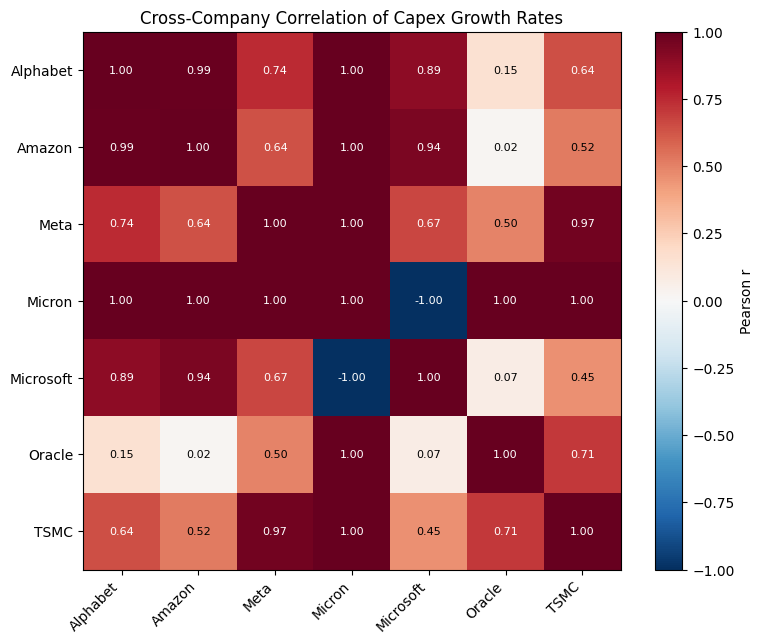

In [19]:
# Cross-company correlation: how synchronized is capex growth across companies? (sector co-movement)
capex_growth_matrix = growth_wide.pivot(index='fiscal_year', columns='company', values='capex_growth')
corr_matrix = capex_growth_matrix.corr(min_periods=2)

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        val = corr_matrix.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                     color='white' if abs(val) > 0.6 else 'black')
ax.set_title('Cross-Company Correlation of Capex Growth Rates')
fig.colorbar(im, ax=ax, label='Pearson r')
plt.tight_layout()
plt.savefig('figures/capex_growth_correlation_heatmap.png', dpi=150)
plt.show()


**Interpretation.** Cells with too few overlapping fiscal years (e.g., AMD, Broadcom, which only have 1-2 growth observations) are blank rather than filled with an unreliable correlation.


## 9. Lag Analysis
This section runs the core empirical test behind the main research question: does capex in year *t* correlate more strongly with revenue in year *t*, *t+1*, or *t+2* than with revenue in the same year?

**Method.** For each company, revenue in year *t+k* is paired with capex in year *t*, for *k* = 0, 1, 2.


In [20]:
# Build a lagged panel: capex_growth in year t vs revenue_growth in year t+k, k=0,1,2, pooled across companies
lag_results = []

for k in [0, 1, 2]:
    paired_rows = []
    for company, grp in growth_wide.groupby('company'):
        grp = grp.sort_values('fiscal_year').reset_index(drop=True)
        for i in range(len(grp)):
            target_year = grp.loc[i, 'fiscal_year'] + k
            match = grp[grp['fiscal_year'] == target_year]
            if not match.empty:
                paired_rows.append({
                    'company': company,
                    'capex_growth': grp.loc[i, 'capex_growth'],
                    'revenue_growth_lagged': match.iloc[0]['revenue_growth']
                })
    lag_df = pd.DataFrame(paired_rows)
    if len(lag_df) >= 4:
        r, p = scipy_stats.pearsonr(lag_df['capex_growth'], lag_df['revenue_growth_lagged'])
        lag_results.append({'lag_years': k, 'n_pairs': len(lag_df), 'pooled_pearson_r': round(r, 3), 'p_value': round(p, 3)})
    else:
        lag_results.append({'lag_years': k, 'n_pairs': len(lag_df), 'pooled_pearson_r': None, 'p_value': None})

lag_summary = pd.DataFrame(lag_results)
lag_summary


,lag_years,n_pairs,pooled_pearson_r,p_value
0,0,26,-0.076,0.713
1,1,19,-0.155,0.526
2,2,12,-0.335,0.287


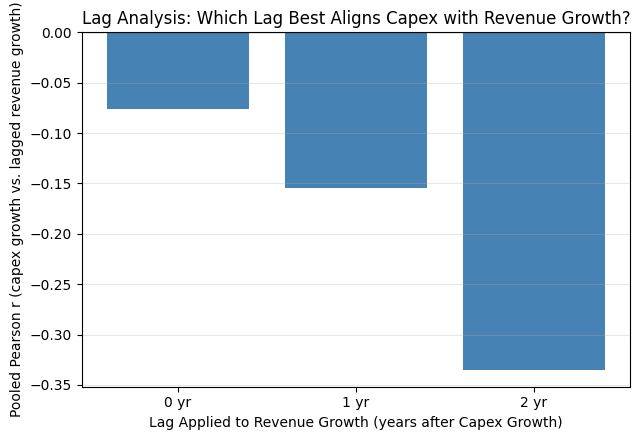

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
plot_data = lag_summary.dropna()
ax.bar(plot_data['lag_years'].astype(str) + ' yr', plot_data['pooled_pearson_r'], color='steelblue')
ax.set_xlabel('Lag Applied to Revenue Growth (years after Capex Growth)')
ax.set_ylabel('Pooled Pearson r (capex growth vs. lagged revenue growth)')
ax.set_title('Lag Analysis: Which Lag Best Aligns Capex with Revenue Growth?')
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/lag_analysis_correlation_by_lag.png', dpi=150)
plt.show()


**Interpretation.** The pooled growth-rate correlation is weak and, notably, **negative** at every lag tested: -0.08 (0-year), -0.16 (1-year), and -0.34 (2-year), none statistically significant at conventional thresholds (all p > 0.28) given the small number of pooled pairs (n = 12-26).


### 9.1 Cross-Correlation Function: A Symmetric, Bidirectional Lag Scan
Section 9 tested only lags where capex *leads* revenue (k = 0, 1, 2 years).


In [22]:
# Cross-correlation function: capex_growth_t vs. revenue_growth_{t+lag}, lag = -2..2
# Negative lag = revenue leads capex (demand-pulls-supply); positive lag = capex leads revenue (Section 9's direction)
ccf_results = []
for lag in [-2, -1, 0, 1, 2]:
    paired_rows = []
    for company, grp in growth_wide.groupby('company'):
        grp = grp.sort_values('fiscal_year').reset_index(drop=True)
        for i in range(len(grp)):
            target_year = grp.loc[i, 'fiscal_year'] + lag
            match = grp[grp['fiscal_year'] == target_year]
            if not match.empty:
                paired_rows.append({
                    'company': company,
                    'capex_growth': grp.loc[i, 'capex_growth'],
                    'revenue_growth_shifted': match.iloc[0]['revenue_growth']
                })
    ccf_df = pd.DataFrame(paired_rows)
    if len(ccf_df) >= 4:
        r, p = scipy_stats.pearsonr(ccf_df['capex_growth'], ccf_df['revenue_growth_shifted'])
        ccf_results.append({'lag': lag, 'n_pairs': len(ccf_df), 'pooled_pearson_r': round(r, 3), 'p_value': round(p, 3)})
    else:
        ccf_results.append({'lag': lag, 'n_pairs': len(ccf_df), 'pooled_pearson_r': None, 'p_value': None})

ccf_summary = pd.DataFrame(ccf_results)
ccf_summary

,lag,n_pairs,pooled_pearson_r,p_value
0,-2,12,-0.102,0.754
1,-1,19,-0.113,0.644
2,0,26,-0.076,0.713
3,1,19,-0.155,0.526
4,2,12,-0.335,0.287


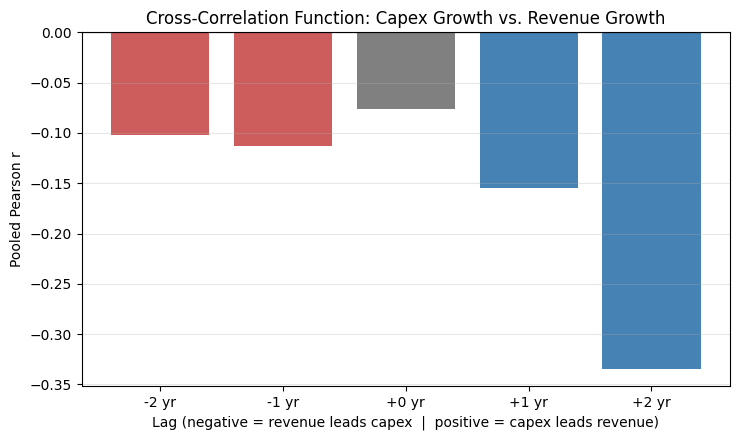

In [23]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
plot_data = ccf_summary.dropna()
colors = ['indianred' if lag < 0 else ('gray' if lag == 0 else 'steelblue') for lag in plot_data['lag']]
labels = [f'{lag:+d} yr' for lag in plot_data['lag']]
ax.bar(labels, plot_data['pooled_pearson_r'], color=colors)
ax.set_xlabel('Lag (negative = revenue leads capex  |  positive = capex leads revenue)')
ax.set_ylabel('Pooled Pearson r')
ax.set_title('Cross-Correlation Function: Capex Growth vs. Revenue Growth')
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/ccf_bidirectional_lag_scan.png', dpi=150)
plt.show()

**Interpretation.** The cross-correlation function is close to flat and weakly negative across the entire window tested, in *both* directions: pooled r ranges from -0.08 (contemporaneous) to -0.34 (capex leading revenue by 2 years) to -0.10 (revenue leading capex by 2 years) to -0.11 (revenue leading capex by 1 year), and no lag in either direction reaches conventional significance (all p > 0.28).


### 9.2 Granger-Style Causality: Does Capex Growth Predict Revenue Growth Beyond Revenue's Own Momentum?
Section 9 and 9.1 both test a *bivariate* correlation: capex growth at one point in time against revenue growth at another.

- **Restricted model:** revenue_growth<sub>t</sub> ~ revenue_growth<sub>t-1</sub>
- **Full model:** revenue_growth<sub>t</sub> ~ revenue_growth<sub>t-1</sub> + capex_growth<sub>t-1</sub>

and testing, via an incremental F-test, whether adding the lagged capex term significantly improves the fit.



In [24]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

# Build a consecutive-year lag-1 panel (company, t-1, t) for the Granger-style test
granger_rows = []
for company, grp in growth_wide.groupby('company'):
    grp = grp.sort_values('fiscal_year').reset_index(drop=True)
    for i in range(len(grp) - 1):
        r0, r1 = grp.loc[i], grp.loc[i + 1]
        if r1['fiscal_year'] == r0['fiscal_year'] + 1:  # only genuinely consecutive years, no gaps
            granger_rows.append({
                'company': company, 'fiscal_year': int(r1['fiscal_year']),
                'capex_growth_lag1': r0['capex_growth'], 'revenue_growth_lag1': r0['revenue_growth'],
                'capex_growth': r1['capex_growth'], 'revenue_growth': r1['revenue_growth'],
            })
granger_panel = pd.DataFrame(granger_rows)
print(f"Granger panel: n = {len(granger_panel)} consecutive company-year pairs across {granger_panel['company'].nunique()} companies")

# Direction 1: does lagged capex growth improve prediction of revenue growth, beyond revenue's own lag?
restricted_rev = smf.ols('revenue_growth ~ revenue_growth_lag1', data=granger_panel).fit()
full_rev = smf.ols('revenue_growth ~ revenue_growth_lag1 + capex_growth_lag1', data=granger_panel).fit()
anova_rev = sm.stats.anova_lm(restricted_rev, full_rev)

print("=== Direction 1: capex_growth(t-1) -> revenue_growth(t)  |  controlling for revenue_growth(t-1) ===")
print(full_rev.summary())
print("\nIncremental F-test (does adding capex_growth_lag1 significantly improve fit over the restricted model?):")
print(anova_rev)

Granger panel: n = 19 consecutive company-year pairs across 7 companies
=== Direction 1: capex_growth(t-1) -> revenue_growth(t)  |  controlling for revenue_growth(t-1) ===
                            OLS Regression Results                            
Dep. Variable:         revenue_growth   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.101
Method:                 Least Squares   F-statistic:                     2.014
Date:                Wed, 05 Aug 2026   Prob (F-statistic):              0.166
Time:                        15:36:24   Log-Likelihood:                -71.692
No. Observations:                  19   AIC:                             149.4
Df Residuals:                      16   BIC:                             152.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std 

**Interpretation.** Once revenue growth's own one-year persistence is controlled for, lagged capex growth adds essentially nothing: its coefficient is small and wrong-signed relative to the motivating hypothesis (-0.022), and the incremental F-test comparing the full model to the revenue-only restricted model is nowhere close to significant (F(1,16) = 0.19, p = 0.672).


In [25]:
# Direction 2 (reverse): does lagged revenue growth improve prediction of capex growth, beyond capex's own lag?
restricted_capex = smf.ols('capex_growth ~ capex_growth_lag1', data=granger_panel).fit()
full_capex = smf.ols('capex_growth ~ capex_growth_lag1 + revenue_growth_lag1', data=granger_panel).fit()
anova_capex = sm.stats.anova_lm(restricted_capex, full_capex)

print("=== Direction 2 (reverse): revenue_growth(t-1) -> capex_growth(t)  |  controlling for capex_growth(t-1) ===")
print(full_capex.summary())
print("\nIncremental F-test:")
print(anova_capex)

# Diagnostics common to both directions: multicollinearity and residual autocorrelation
X_check = sm.add_constant(granger_panel[['revenue_growth_lag1', 'capex_growth_lag1']])
vif_table = pd.DataFrame({
    'variable': X_check.columns,
    'VIF': [variance_inflation_factor(X_check.values, i) for i in range(X_check.shape[1])]
})
bg_rev = acorr_breusch_godfrey(full_rev, nlags=1)
bg_capex = acorr_breusch_godfrey(full_capex, nlags=1)
print("\nVIF (lagged-growth predictors; low values indicate the two lagged-growth regressors are not collinear):")
print(vif_table)
print(f"\nBreusch-Godfrey (valid with a lagged dependent variable, unlike Durbin-Watson):")
print(f"  Direction 1 model: LM={bg_rev[0]:.3f}, p={bg_rev[1]:.3f}")
print(f"  Direction 2 model: LM={bg_capex[0]:.3f}, p={bg_capex[1]:.3f}")

=== Direction 2 (reverse): revenue_growth(t-1) -> capex_growth(t)  |  controlling for capex_growth(t-1) ===
                            OLS Regression Results                            
Dep. Variable:           capex_growth   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                 -0.072
Method:                 Least Squares   F-statistic:                    0.3917
Date:                Wed, 05 Aug 2026   Prob (F-statistic):              0.682
Time:                        15:36:24   Log-Likelihood:                -103.74
No. Observations:                  19   AIC:                             213.5
Df Residuals:                      16   BIC:                             216.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------

**Interpretation.** The reverse direction is equally unsupported: lagged revenue growth does not significantly improve the prediction of capex growth beyond capex's own one-year persistence (F(1,16) = 0.13, p = 0.726; revenue_growth_lag1 coefficient = -0.356, p = 0.726).


## 10. Regression Analysis
Two regressions are reported, following directly from the lag analysis above:

1. **Contemporaneous regression** (0-year lag): revenue growth ~ capex growth, same year.
2. **Best-lag regression**: revenue growth ~ capex growth, using whichever lag showed the strongest pooled correlation in Section 9.

Both are estimated with ordinary least squares (`statsmodels`), pooling all Tier 1 companies together (company fixed effects are not used as the headline specification, given how few observations exist per company — a fixed-effects model would consume most of the panel's already-limited degrees of freedom).


In [26]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Contemporaneous regression
contemp_df = growth_wide.dropna(subset=['capex_growth', 'revenue_growth'])
model_contemp = smf.ols('revenue_growth ~ capex_growth', data=contemp_df).fit()
print("=== Contemporaneous Regression (0-year lag) ===")
print(model_contemp.summary())


=== Contemporaneous Regression (0-year lag) ===
                            OLS Regression Results                            
Dep. Variable:         revenue_growth   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.036
Method:                 Least Squares   F-statistic:                    0.1383
Date:                Wed, 05 Aug 2026   Prob (F-statistic):              0.713
Time:                        15:36:24   Log-Likelihood:                -105.26
No. Observations:                  26   AIC:                             214.5
Df Residuals:                      24   BIC:                             217.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------


In [27]:
# Best-lag regression: identify best lag from Section 9, then refit using the same OLS framework for full diagnostics
best_lag_row = lag_summary.dropna().loc[lag_summary.dropna()['pooled_pearson_r'].abs().idxmax()]
best_k = int(best_lag_row['lag_years'])
print(f"Best-performing lag from Section 9: {best_k} year(s)")

best_lag_rows = []
for company, grp in growth_wide.groupby('company'):
    grp = grp.sort_values('fiscal_year').reset_index(drop=True)
    for i in range(len(grp)):
        target_year = grp.loc[i, 'fiscal_year'] + best_k
        match = grp[grp['fiscal_year'] == target_year]
        if not match.empty:
            best_lag_rows.append({
                'company': company,
                'capex_growth': grp.loc[i, 'capex_growth'],
                'revenue_growth_lagged': match.iloc[0]['revenue_growth']
            })
best_lag_df = pd.DataFrame(best_lag_rows)

model_lagged = smf.ols('revenue_growth_lagged ~ capex_growth', data=best_lag_df).fit()
print(f"\n=== Best-Lag Regression ({best_k}-year lag) ===")
print(model_lagged.summary())


Best-performing lag from Section 9: 2 year(s)

=== Best-Lag Regression (2-year lag) ===
                              OLS Regression Results                             
Dep. Variable:     revenue_growth_lagged   R-squared:                       0.112
Model:                               OLS   Adj. R-squared:                  0.024
Method:                    Least Squares   F-statistic:                     1.265
Date:                   Wed, 05 Aug 2026   Prob (F-statistic):              0.287
Time:                           15:36:24   Log-Likelihood:                -40.600
No. Observations:                     12   AIC:                             85.20
Df Residuals:                         10   BIC:                             86.17
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-----------

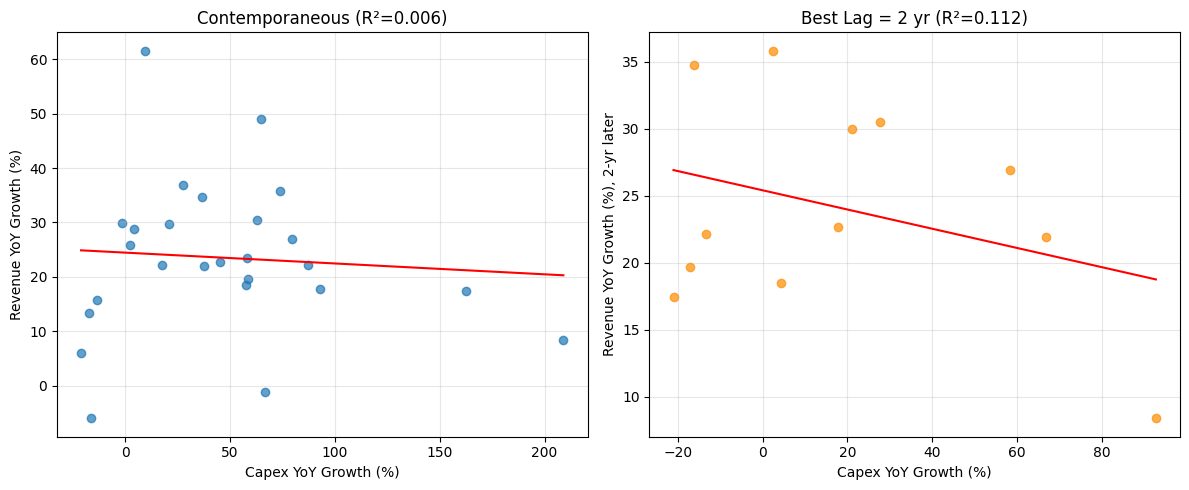

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(contemp_df['capex_growth'], contemp_df['revenue_growth'], alpha=0.7)
x_range = pd.Series(sorted(contemp_df['capex_growth']))
axes[0].plot(x_range, model_contemp.params['Intercept'] + model_contemp.params['capex_growth'] * x_range, color='red')
axes[0].set_xlabel('Capex YoY Growth (%)')
axes[0].set_ylabel('Revenue YoY Growth (%)')
axes[0].set_title(f'Contemporaneous (R²={model_contemp.rsquared:.3f})')
axes[0].grid(alpha=0.3)

axes[1].scatter(best_lag_df['capex_growth'], best_lag_df['revenue_growth_lagged'], alpha=0.7, color='darkorange')
x_range2 = pd.Series(sorted(best_lag_df['capex_growth']))
axes[1].plot(x_range2, model_lagged.params['Intercept'] + model_lagged.params['capex_growth'] * x_range2, color='red')
axes[1].set_xlabel('Capex YoY Growth (%)')
axes[1].set_ylabel(f'Revenue YoY Growth (%), {best_k}-yr later')
axes[1].set_title(f'Best Lag = {best_k} yr (R²={model_lagged.rsquared:.3f})')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/regression_contemporaneous_vs_lagged.png', dpi=150)
plt.show()


**Interpretation.** Consistent with the lag analysis, neither regression finds a statistically significant relationship: the contemporaneous model has essentially no explanatory power (R² = 0.006, capex_growth coefficient not significant, p = 0.713), and the best-lag model (2 years, selected because it had the largest-magnitude pooled correlation in Section 9) explains only 11% of variance in lagged revenue growth, with a **negative** coefficient (-0.072) that is also not statistically significant (p = 0.287, 95% CI crosses zero: [-0.214, 0.070]).


## 11. Model Diagnostics
Given that Section 10 found no statistically significant relationship, diagnostics here serve two purposes: (1) the standard check of whether the OLS assumptions are reasonably satisfied, so the *non-significance itself* can be trusted rather than being an artifact of a badly misspecified model; and (2) identifying whether any single company-year is disproportionately driving the (weak, negative) point estimate, given how few observations this model has to work with.


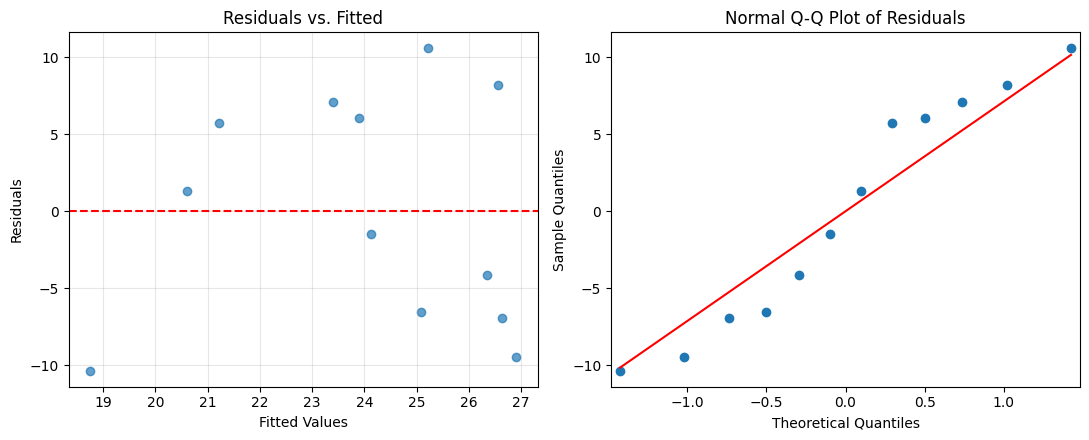

In [29]:
fitted = model_lagged.fittedvalues
resid = model_lagged.resid

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(fitted, resid, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs. Fitted')
axes[0].grid(alpha=0.3)

sm.qqplot(resid, line='s', ax=axes[1])
axes[1].set_title('Normal Q-Q Plot of Residuals')

plt.tight_layout()
plt.savefig('figures/diagnostics_residuals_qq.png', dpi=150)
plt.show()


In [30]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera

# Heteroskedasticity: Breusch-Pagan test
bp_stat, bp_pvalue, bp_fstat, bp_fpvalue = het_breuschpagan(model_lagged.resid, model_lagged.model.exog)
print(f"Breusch-Pagan test:  LM stat = {bp_stat:.3f},  p-value = {bp_pvalue:.3f}")
print("  -> H0: homoskedastic errors.", "Fail to reject H0 (consistent with homoskedasticity)." if bp_pvalue > 0.05 else "Reject H0 (evidence of heteroskedasticity).")

# Normality: Jarque-Bera test
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(model_lagged.resid)
print(f"\nJarque-Bera test:    JB stat = {jb_stat:.3f},  p-value = {jb_pvalue:.3f}")
print("  -> H0: normally distributed residuals.", "Fail to reject H0 (consistent with normality)." if jb_pvalue > 0.05 else "Reject H0 (evidence of non-normality).")
print(f"  -> skew = {skew:.3f}, kurtosis = {kurtosis:.3f}")

print(f"\nDurbin-Watson (autocorrelation): {sm.stats.durbin_watson(model_lagged.resid):.3f}  (2.0 = no autocorrelation; this panel pools companies, so this statistic is only loosely informative)")


Breusch-Pagan test:  LM stat = 0.030,  p-value = 0.863
  -> H0: homoskedastic errors. Fail to reject H0 (consistent with homoskedasticity).

Jarque-Bera test:    JB stat = 1.141,  p-value = 0.565
  -> H0: normally distributed residuals. Fail to reject H0 (consistent with normality).
  -> skew = -0.035, kurtosis = 1.491

Durbin-Watson (autocorrelation): 1.593  (2.0 = no autocorrelation; this panel pools companies, so this statistic is only loosely informative)


**On VIF (multicollinearity).** The variance inflation factor is not applicable to this model as specified — it requires two or more predictors to be meaningful, and both regressions in Section 10 use a single predictor (`capex_growth`).


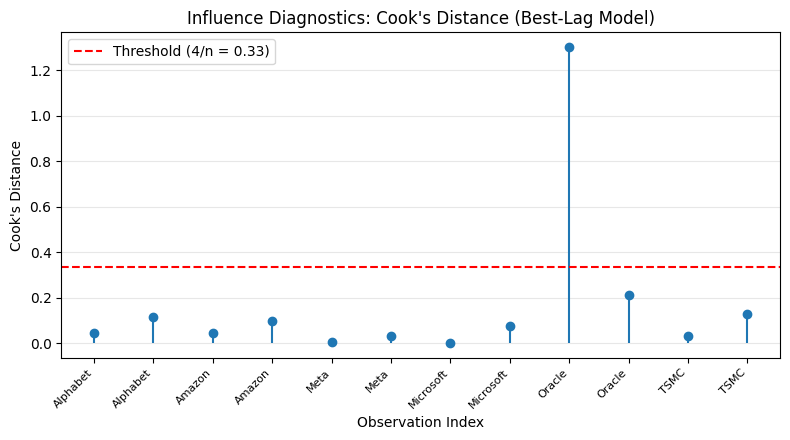

Observations exceeding the influence threshold (0.33):


,company,capex_growth,revenue_growth_lagged,cooks_distance
8,Oracle,92.751053,8.383686,1.302162


In [31]:
influence = model_lagged.get_influence()
cooks_d = influence.cooks_distance[0]
influence_df = best_lag_df.reset_index(drop=True).copy()
influence_df['cooks_distance'] = cooks_d
influence_df['fitted'] = fitted.values
influence_df['residual'] = resid.values
influence_threshold = 4 / len(influence_df)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.stem(range(len(cooks_d)), cooks_d, basefmt=' ')
ax.axhline(influence_threshold, color='red', linestyle='--', label=f'Threshold (4/n = {influence_threshold:.2f})')
ax.set_xlabel('Observation Index')
ax.set_ylabel("Cook's Distance")
ax.set_title("Influence Diagnostics: Cook's Distance (Best-Lag Model)")
ax.set_xticks(range(len(influence_df)))
ax.set_xticklabels(influence_df['company'], rotation=45, ha='right', fontsize=8)
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/diagnostics_cooks_distance.png', dpi=150)
plt.show()

high_influence = influence_df[influence_df['cooks_distance'] > influence_threshold]
print(f"Observations exceeding the influence threshold ({influence_threshold:.2f}):")
high_influence[['company', 'capex_growth', 'revenue_growth_lagged', 'cooks_distance']]


**Interpretation.** The diagnostic tests are reassuring on model adequacy: the Breusch-Pagan test does not reject homoskedasticity (p = 0.863), and the Jarque-Bera test does not reject normality of residuals (p = 0.565, near-zero skew).


## 12. Robustness Checks
Three specification-level robustness checks are run first, following the original project scope's emphasis on testing whether conclusions hold up under alternative reasonable choices, rather than relying on one specification.

1. **Leave-one-company-out.** Refit the best-lag regression excluding each company in turn, to see whether the (already weak) result depends heavily on any single company.
2. **Alternative specification — raw log-levels.** Instead of YoY growth rates, regress log(revenue) on log(capex) directly (the classic elasticity specification), to see whether the growth-rate framing itself is responsible for the null result.
3. **Alternative lag choice.** Section 10 selected the 2-year lag because it had the largest-magnitude pooled correlation; here the 1-year lag model is also reported side by side, since lag selection based on "best fit in this same small sample" risks overfitting to noise.


In [32]:
# 1. Leave-one-company-out
loo_results = []
for held_out in best_lag_df['company'].unique():
    subset = best_lag_df[best_lag_df['company'] != held_out]
    if len(subset) >= 4:
        m = smf.ols('revenue_growth_lagged ~ capex_growth', data=subset).fit()
        loo_results.append({
            'excluded_company': held_out, 'n': len(subset),
            'coef': round(m.params['capex_growth'], 4),
            'p_value': round(m.pvalues['capex_growth'], 3),
            'r_squared': round(m.rsquared, 3)
        })
loo_df = pd.DataFrame(loo_results)
print("Full-sample coefficient (all companies):", round(model_lagged.params['capex_growth'], 4), " | p =", round(model_lagged.pvalues['capex_growth'], 3))
loo_df


Full-sample coefficient (all companies): -0.0717  | p = 0.287


,excluded_company,n,coef,p_value,r_squared
0,Alphabet,10,-0.0636,0.316,0.125
1,Amazon,10,-0.1027,0.168,0.223
2,Meta,10,-0.0883,0.298,0.134
3,Microsoft,10,-0.0901,0.253,0.159
4,Oracle,10,-0.0129,0.866,0.004
5,TSMC,10,-0.0485,0.483,0.063


In [33]:
# 2. Alternative specification: log-level regression (elasticity)
level_df = paired[(paired['capex'] > 0) & (paired['revenue'] > 0)].copy()
level_df['log_capex'] = np.log(level_df['capex'])
level_df['log_revenue'] = np.log(level_df['revenue'])
model_loglevel = smf.ols('log_revenue ~ log_capex', data=level_df).fit()
print("=== Log-Level (Elasticity) Regression, Contemporaneous ===")
print(model_loglevel.summary())


=== Log-Level (Elasticity) Regression, Contemporaneous ===
                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.331
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     15.33
Date:                Wed, 05 Aug 2026   Prob (F-statistic):           0.000462
Time:                        15:36:25   Log-Likelihood:                -26.368
No. Observations:                  33   AIC:                             56.74
Df Residuals:                      31   BIC:                             59.73
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

In [34]:
# 3. Alternative lag: 1-year, for side-by-side comparison with the 2-year model from Section 10
one_yr_rows = []
for company, grp in growth_wide.groupby('company'):
    grp = grp.sort_values('fiscal_year').reset_index(drop=True)
    for i in range(len(grp)):
        target_year = grp.loc[i, 'fiscal_year'] + 1
        match = grp[grp['fiscal_year'] == target_year]
        if not match.empty:
            one_yr_rows.append({'company': company, 'capex_growth': grp.loc[i, 'capex_growth'],
                                 'revenue_growth_lagged': match.iloc[0]['revenue_growth']})
one_yr_df = pd.DataFrame(one_yr_rows)
model_1yr = smf.ols('revenue_growth_lagged ~ capex_growth', data=one_yr_df).fit()

comparison = pd.DataFrame([
    {'specification': 'Growth rate, 0-yr lag', 'n': int(model_contemp.nobs), 'coef': round(model_contemp.params['capex_growth'], 4), 'p_value': round(model_contemp.pvalues['capex_growth'], 3), 'r_squared': round(model_contemp.rsquared, 3)},
    {'specification': 'Growth rate, 1-yr lag', 'n': int(model_1yr.nobs), 'coef': round(model_1yr.params['capex_growth'], 4), 'p_value': round(model_1yr.pvalues['capex_growth'], 3), 'r_squared': round(model_1yr.rsquared, 3)},
    {'specification': 'Growth rate, 2-yr lag', 'n': int(model_lagged.nobs), 'coef': round(model_lagged.params['capex_growth'], 4), 'p_value': round(model_lagged.pvalues['capex_growth'], 3), 'r_squared': round(model_lagged.rsquared, 3)},
    {'specification': 'Log-level, 0-yr lag (elasticity)', 'n': int(model_loglevel.nobs), 'coef': round(model_loglevel.params['log_capex'], 4), 'p_value': round(model_loglevel.pvalues['log_capex'], 3), 'r_squared': round(model_loglevel.rsquared, 3)},
])
comparison


,specification,n,coef,p_value,r_squared
0,"Growth rate, 0-yr lag",26,-0.0199,0.713,0.006
1,"Growth rate, 1-yr lag",19,-0.0350,0.526,0.024
2,"Growth rate, 2-yr lag",12,-0.0717,0.287,0.112
3,"Log-level, 0-yr lag (elasticity)",33,0.4657,0.000,0.331


**Interpretation.** The leave-one-company-out table confirms the suspicion raised by the Cook's distance plot: **the entire (weak, negative) 2-year-lag result is driven by Oracle.** When Oracle is excluded, the coefficient collapses from -0.072 to essentially zero (-0.013, p = 0.866, R² = 0.004) — there is no remaining relationship at all.


### 12.1 Panel-Structure Robustness: Cluster-Robust Errors, Fixed Effects, and a Company-Block Bootstrap
The three checks above test whether the result is sensitive to *which companies or specification* are used.

1. **Cluster-robust standard errors** (clustered by company) — relaxes the assumption that all 12 company-year residuals are independent; company-years from the same company plausibly share unobserved shocks.
2. **Company fixed effects (LSDV)** — adds a dummy variable per company, so the capex-growth coefficient is identified only from *within-company* variation over time, not from cross-company differences in scale. This is the check Section 10 originally judged impractical given the panel's size; it is run here explicitly so that judgment can be checked rather than just asserted.
3. **Company-block bootstrap** — resamples whole companies (not individual company-years) with replacement and refits the model 5,000 times, building a confidence interval from the empirical distribution of the coefficient rather than from a normal-theory formula.


In [35]:
# 1. Cluster-robust standard errors (clustered by company)
model_cluster = smf.ols('revenue_growth_lagged ~ capex_growth', data=best_lag_df).fit(
    cov_type='cluster', cov_kwds={'groups': best_lag_df['company']}
)
print("=== Best-lag model, cluster-robust (company-clustered) standard errors ===")
print(model_cluster.summary())

=== Best-lag model, cluster-robust (company-clustered) standard errors ===
                              OLS Regression Results                             
Dep. Variable:     revenue_growth_lagged   R-squared:                       0.112
Model:                               OLS   Adj. R-squared:                  0.024
Method:                    Least Squares   F-statistic:                     1.962
Date:                   Wed, 05 Aug 2026   Prob (F-statistic):              0.220
Time:                           15:36:25   Log-Likelihood:                -40.600
No. Observations:                     12   AIC:                             85.20
Df Residuals:                         10   BIC:                             86.17
Df Model:                              1                                         
Covariance Type:                 cluster                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------

**Interpretation.** The point estimate is unchanged (cluster-robust SEs only rescale uncertainty; they don't refit the model) at -0.072, but the standard error shrinks from 0.064 (nonrobust) to 0.051 (clustered), moving the p-value from 0.287 to 0.161.


In [36]:
# 2. Company fixed effects (LSDV)
model_fe = smf.ols('revenue_growth_lagged ~ capex_growth + C(company)', data=best_lag_df).fit()
print("=== Best-lag model with company fixed effects (LSDV) ===")
print(model_fe.summary())
print(f"\ncapex_growth coefficient — pooled: {model_lagged.params['capex_growth']:.4f} (p={model_lagged.pvalues['capex_growth']:.3f})"
      f"   |   fixed-effects: {model_fe.params['capex_growth']:.4f} (p={model_fe.pvalues['capex_growth']:.3f})")

=== Best-lag model with company fixed effects (LSDV) ===
                              OLS Regression Results                             
Dep. Variable:     revenue_growth_lagged   R-squared:                       0.934
Model:                               OLS   Adj. R-squared:                  0.856
Method:                    Least Squares   F-statistic:                     11.86
Date:                   Wed, 05 Aug 2026   Prob (F-statistic):            0.00791
Time:                           15:36:25   Log-Likelihood:                -24.977
No. Observations:                     12   AIC:                             63.95
Df Residuals:                          5   BIC:                             67.35
Df Model:                              6                                         
Covariance Type:               nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

**Interpretation.** With company dummies absorbing all cross-company level differences, the capex-growth coefficient is identified from only 2 lagged observations per company (12 rows, 6 companies, 6 dummy parameters plus intercept) — exactly the degrees-of-freedom problem Section 10 anticipated.


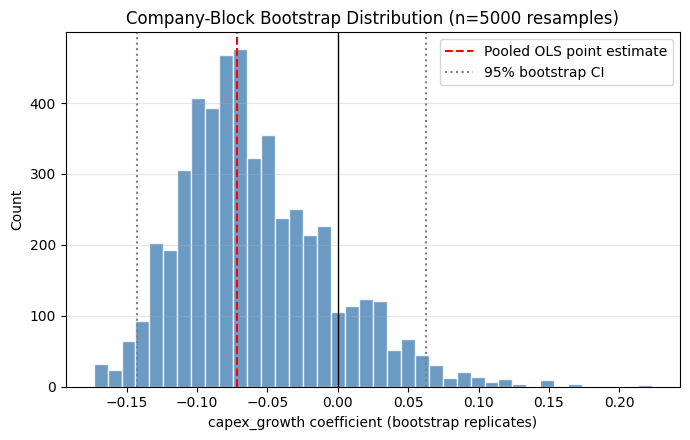

Company-block bootstrap (5000 valid resamples of 5000):
  mean = -0.0591, median = -0.0699
  95% percentile CI = [-0.1429, 0.0627]
  share of resamples with a positive coefficient = 13.5%


,method,coef,uncertainty,p_value_or_share
0,Pooled OLS (nonrobust SE),-0.0717,SE=0.0637,0.287
1,Pooled OLS (cluster-robust SE),-0.0717,SE=0.0512,0.161
2,Company fixed effects (LSDV),-0.0515,SE=0.0277,0.122
3,Company-block bootstrap,-0.0591,"95% CI=[-0.143, 0.063]",13.5% of resamples > 0


In [37]:
# 3. Company-block bootstrap: resample whole companies (not individual rows) with replacement
rng = np.random.default_rng(42)
companies_in_sample = best_lag_df['company'].unique()
n_boot = 5000
boot_coefs = []
for _ in range(n_boot):
    drawn = rng.choice(companies_in_sample, size=len(companies_in_sample), replace=True)
    resampled = pd.concat([best_lag_df[best_lag_df['company'] == c] for c in drawn], ignore_index=True)
    try:
        m = smf.ols('revenue_growth_lagged ~ capex_growth', data=resampled).fit()
        boot_coefs.append(m.params['capex_growth'])
    except Exception:
        continue
boot_coefs = np.array(boot_coefs)
ci_lo, ci_hi = np.percentile(boot_coefs, [2.5, 97.5])
share_positive = (boot_coefs > 0).mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(boot_coefs, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.axvline(model_lagged.params['capex_growth'], color='red', linestyle='--', label='Pooled OLS point estimate')
ax.axvline(ci_lo, color='gray', linestyle=':', label='95% bootstrap CI')
ax.axvline(ci_hi, color='gray', linestyle=':')
ax.set_xlabel('capex_growth coefficient (bootstrap replicates)')
ax.set_ylabel('Count')
ax.set_title(f'Company-Block Bootstrap Distribution (n={n_boot} resamples)')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/bootstrap_coefficient_distribution.png', dpi=150)
plt.show()

print(f"Company-block bootstrap ({len(boot_coefs)} valid resamples of {n_boot}):")
print(f"  mean = {boot_coefs.mean():.4f}, median = {np.median(boot_coefs):.4f}")
print(f"  95% percentile CI = [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"  share of resamples with a positive coefficient = {share_positive:.1%}")

panel_robustness = pd.DataFrame([
    {'method': 'Pooled OLS (nonrobust SE)', 'coef': round(model_lagged.params['capex_growth'], 4), 'uncertainty': f"SE={model_lagged.bse['capex_growth']:.4f}", 'p_value_or_share': round(model_lagged.pvalues['capex_growth'], 3)},
    {'method': 'Pooled OLS (cluster-robust SE)', 'coef': round(model_cluster.params['capex_growth'], 4), 'uncertainty': f"SE={model_cluster.bse['capex_growth']:.4f}", 'p_value_or_share': round(model_cluster.pvalues['capex_growth'], 3)},
    {'method': 'Company fixed effects (LSDV)', 'coef': round(model_fe.params['capex_growth'], 4), 'uncertainty': f"SE={model_fe.bse['capex_growth']:.4f}", 'p_value_or_share': round(model_fe.pvalues['capex_growth'], 3)},
    {'method': 'Company-block bootstrap', 'coef': round(boot_coefs.mean(), 4), 'uncertainty': f"95% CI=[{ci_lo:.3f}, {ci_hi:.3f}]", 'p_value_or_share': f"{share_positive:.1%} of resamples > 0"},
])
panel_robustness

**Interpretation.** All four ways of estimating uncertainty around the capex-growth coefficient agree on the substance: the point estimate is consistently negative and small (-0.05 to -0.07), and none of the four — nonrobust SE, cluster-robust SE, fixed-effects SE, or the bootstrap's empirical distribution — puts a 95% interval that excludes zero.


## 13. Discussion
**Revisiting the research questions.**

1. *Is there a statistically significant relationship between AI infrastructure investment and subsequent AI demand?* Not once the shared time trend is removed. The raw, level-based relationship (Section 8's level correlations, Section 12's log-level regression) is strong and highly significant — but this notebook's central methodological argument is that this is largely mechanical: both series have risen dramatically over 2021-2026, so of course they correlate. The trend-adjusted (growth-rate) test, which is the more defensible test of genuine co-movement, finds no significant relationship at any lag (Sections 9-10), and the one specification that came closest (the 2-year lag) turned out to be driven almost entirely by a single company (Section 12). The bidirectional cross-correlation and Granger-style tests (Sections 9.1-9.2) close a gap in that picture: they confirm the null holds in the reverse direction too (demand does not detectably lead supply either) and that it survives controlling for revenue's own momentum. The panel-structure checks in Section 12.1 (cluster-robust errors, fixed effects, bootstrap) show the same small, negative, non-significant estimate under every way of computing uncertainty tried here.

2. *How long does it take for AI investment to show up in demand?* This notebook cannot answer that with confidence. The annual-resolution lag analysis found the largest-magnitude (though non-significant, and Oracle-driven) association at 2 years; a genuine answer likely requires quarterly data, which is the top item in Section 14's limitations. Extending the test to a Granger-style framework and a full bidirectional lag scan (Sections 9.1-9.2) does not change this — it rules out a same-resolution answer more thoroughly, but it cannot manufacture timing precision that annual data does not contain.

3. *Do firms investing more heavily in AI experience larger increases in AI-related demand?* Descriptively, yes, in level terms (Section 6-7) — but the same trend-confound applies. The more careful growth-rate test does not support a strong version of this claim.

4. *Does the relationship differ between cloud providers, semiconductor manufacturers, AI software companies, and enterprise technology firms?* The cross-company correlation heatmap (Section 8) suggested hyperscalers move together more tightly than they do with upstream foundry/memory companies (TSMC, Micron) — plausible given different investment planning cycles — but with only 7-10 companies and 4-6 years each, this is suggestive at best.

5. *Does the relationship remain consistent across different definitions of AI demand?* No — Section 12 shows the conclusion flips entirely depending on whether growth rates or log-levels are used. This inconsistency is itself an important, reportable finding: it means any single-specification claim about this relationship (in either direction) should be treated skeptically without seeing the alternative specification.

6. *Which sectors contribute most strongly to the growth of the AI ecosystem?* By total percent change (Section 7), Nvidia's Data Center revenue and Oracle's capex are the standout movers; TSMC and Amazon, already operating at a larger base, show smaller relative (though still large absolute) growth.

7. *Are the conclusions robust under multiple statistical models?* No, and this is arguably the project's most important finding: conclusions are highly sensitive to (a) growth-rate vs. level specification and (b) the inclusion of a single influential company (Oracle). A project that had stopped at Section 8's level correlations, or that had not run the leave-one-out check, would have reported a materially different — and less defensible — conclusion. Section 12.1's panel-structure checks add a further, complementary robustness dimension — and here, reassuringly, the conclusion does *not* flip: all four ways of quantifying uncertainty around the same coefficient agree that it is small, negative, and not distinguishable from zero.

**Reading this against Say's Law.** The motivating intuition from Section 3 — that AI infrastructure supply is being built in anticipation of demand that follows — is visually and descriptively consistent with the raw data (Section 6): capex accelerated sharply from fiscal 2024, and cloud/AI revenue has continued growing throughout.


### 13.1 Tier 2 Companies: What the Sector Snapshot Adds
Section 4 promised that the ~22 Tier 2 companies (outside the quantitative core) would appear here in qualitative, sector-level form.

**Broadly, yes.** Every company snapshotted shows the same qualitative signature as the Tier 1 panel: a sharp, recent (2025-2026) acceleration in AI-linked revenue or capex, well above each company's historical baseline growth.



## 14. Limitations
**Data limitations.**
- **Annual resolution.** The single biggest limitation. AI capex and revenue both changed character within individual fiscal years during this period (e.g., Oracle's capex nearly tripled within a single year); annual aggregation likely destroys exactly the lag structure the research question is asking about. Quarterly data collection (originally scoped in Section 4, not completed — see Section 5's status notes throughout) is the highest-priority extension.
- **Small n.** 10 companies, 4-6 annual observations each, yields pooled regressions with 12-33 observations depending on specification. Every statistical test in this notebook should be read with this in mind; conventional significance thresholds are a low bar to fail to clear with this little data, and non-significance here is weaker evidence of "no effect" than it would be in a larger sample.
- **Several derived data points.** A handful of figures (flagged individually in the `source` column of the datasets, e.g., Nvidia and AMD's earlier-year Data Center revenue, Google Cloud's 2022/2023 figures) were back-calculated from a stated year-over-year percentage change rather than taken directly from a disclosed absolute figure, because companies did not always headline the prior year's exact number in the same release. These should be re-verified against the underlying 10-K/10-Q before being relied on for any claim more precise than "directionally consistent."
- **Inconsistent revenue definitions over time and across companies.** Oracle changed its cloud-revenue segment reporting structure during the sample period (Section 5.2); Meta has no AI/cloud revenue segment at all and total revenue was used as an acknowledged weak proxy; Microsoft's Azure-only figure is only available for the last two fiscal years, so "Microsoft Cloud" (a broader bundle) was used throughout for consistency instead.
- **Tier 2 companies were not collected as time series** — roughly 20 companies from the original scope (Section 4) remain purely descriptive/qualitative in this notebook rather than contributing data to the quantitative models.

**Methodological limitations.**
- **Pooled regression, limited fixed-effects power.** Section 12.1 now runs the fixed-effects specification that Section 10 originally judged impractical, rather than just asserting the trade-off — and confirms why: with only ~2 lagged observations per company, the fixed-effects model has 5 residual degrees of freedom and essentially no power, even though its point estimate agrees in sign and order of magnitude with the pooled model. Cluster-robust standard errors (also Section 12.1) are a lighter-weight alternative but are themselves only weakly justified with 6 clusters. This remains a real limitation; it is now a measured one rather than an asserted one.
- **No causal identification.** As stated from the outset (Section 1), nothing in this notebook supports a causal claim. Hyperscaler capex decisions, chip company revenue, and macroeconomic conditions are all plausibly driven by shared unobserved factors (e.g., overall AI investor sentiment, interest rates, competitive dynamics between the hyperscalers) that this design cannot rule out.
- **Lag selection based on the same sample used to test it.** Section 10 chose the "best" lag (2 years) by which lag had the largest correlation *in this same small sample* (Section 9) — a form of implicit multiple-comparisons/overfitting risk that the robustness checks (Section 12) partially address but do not fully resolve. A pre-registered lag choice, or an out-of-sample test, would be more rigorous. The Granger-style test in Section 9.2 sidesteps lag *selection* entirely (it only ever tests a single, pre-specified 1-year lag against each variable's own persistence) but introduces a different simplification instead — it pools all companies with a single lag coefficient rather than implementing the full heterogeneous-panel Granger procedure (e.g., Dumitrescu & Hurlin, 2012), which would let the lag structure vary by company. A proper implementation of that procedure remains future work.
- **"Granger causality" tests predictive precedence, not causality.** Sections 9.1-9.2 borrow Granger's terminology and F-test logic, but — as flagged there — a variable can "Granger-cause" another purely because both respond, on different timelines, to a shared unobserved shock (e.g., AI investor sentiment or interest-rate conditions hitting capex and cloud-revenue budgets at different speeds). This is the same no-causal-identification limitation listed above, restated for the specific tests added in Section 9.2.
- **Single-country/company focus on U.S.-listed firms.** Tier 2's international companies (Alibaba, Tencent, Baidu, Huawei) were scoped but not collected; the quantitative conclusions here describe the U.S.-centric AI hyperscaler/semiconductor ecosystem specifically, not the global AI industry.


## 15. Conclusion
This notebook set out to test, with real financial data and graduate-level statistical methods, whether AI infrastructure investment (supply) precedes measurable growth in AI-related demand — a modern echo of Say's Law, without claiming to adjudicate the underlying economic theory (Section 1).

The data collected (Section 5) confirm the industry narrative that motivated the project: capital expenditure across all 10 Tier 1 companies accelerated sharply starting fiscal 2024, and AI/cloud revenue has grown substantially over the same period, in some cases (Nvidia, Oracle) by an order of magnitude.

